# MatchMind - Chunking Strategies for Football Retrieval

This notebook studies one of the most important design decisions in a Retrieval-Augmented Generation system: **how to divide source information into retrieval units, or chunks**.

The previous notebook used one StatsBomb possession as one retrieval document.

That baseline revealed an important limitation:

```text
246 possession documents
91 documents above 256 tokens
36.99% above the embedding model limit
```

Some possessions contained more than 1,000 tokens, while the current Sentence Transformer processes at most 256 tokens per input.

As a result, encoding complete possessions can discard a substantial part of the available information.

## Objective

The goal of this notebook is not to find a universally perfect chunk size.

Instead, we will compare several chunking strategies and understand their trade-offs:

```text
1. Event-level chunks
2. Whole-possession chunks
3. Fixed token-window chunks
4. Football-aware possession chunks
```

The current embedding model remains:

```text
sentence-transformers/all-MiniLM-L6-v2
```

We intentionally keep the model fixed so that changes in behavior can be attributed to the chunking strategy rather than to a simultaneous model change.

## Questions addressed

By the end of the notebook, we should understand:

- what a chunk is;
- why chunk size matters;
- why model context length and optimal chunk size are different concepts;
- what overlap means;
- why fixed token windows can break football sequences;
- how event boundaries can be preserved;
- how chunking changes the number and length of retrieval documents;
- how different chunking strategies affect semantic retrieval.

No vector database is used yet.

All embeddings and similarity calculations remain local and in memory.

## 1. Project setup

The notebook reuses the existing MatchMind source modules instead of duplicating data-loading or event-formatting logic.

Expected project location:

```text
MatchMind/
├── notebooks/
│   └── 03_chunking_strategies.ipynb
├── src/
├── data/
└── matchmind-env/
```

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()

if (cwd / "src").exists() and (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists() and (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the MatchMind project root. "
        "Start Jupyter from the MatchMind project or its notebooks directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/eldisymeraj/Documents/GitHub/MatchMind


## 2. Imports

This notebook uses the same tokenizer and Sentence Transformer as Notebook 02.

No additional package is required.

In [2]:
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer

from src.data.statsbomb_loader import load_events
from src.text.event_formatter import (
    build_event_documents,
    build_possession_documents,
)

print("Imports loaded successfully.")

/Users/eldisymeraj/Documents/GitHub/MatchMind/matchmind-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports loaded successfully.


## 3. Load MatchMind football documents

We build both event-level and possession-level textual representations from the same raw StatsBomb match.

This ensures that all chunking strategies originate from the same football data.

In [3]:
MATCH_ID = 3869685

events = load_events(MATCH_ID)

event_documents = build_event_documents(
    events,
    include_location=False,
    include_shootout=False,
)

possession_documents = build_possession_documents(
    events,
    include_location=False,
    include_shootout=False,
)

print(f"Raw events: {len(events)}")
print(f"Event documents: {len(event_documents)}")
print(f"Possession documents: {len(possession_documents)}")

Raw events: 4407
Event documents: 3252
Possession documents: 246


## 4. Load the tokenizer and embedding model

The same embedding model used in Notebook 02 is preserved as the baseline.

Keeping the model fixed is important for experimental clarity.

If both the model and the chunking strategy changed at the same time, it would be difficult to know which change caused a retrieval difference.

In [4]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
embedding_model = SentenceTransformer(MODEL_NAME)

MAX_SEQUENCE_LENGTH = embedding_model.max_seq_length
EMBEDDING_DIMENSION = embedding_model.get_sentence_embedding_dimension()

print(f"Model: {MODEL_NAME}")
print(f"Maximum sequence length: {MAX_SEQUENCE_LENGTH}")
print(f"Embedding dimension: {EMBEDDING_DIMENSION}")

Model: sentence-transformers/all-MiniLM-L6-v2
Maximum sequence length: 256
Embedding dimension: 384


# Part I - Understanding Chunking

## 5. What is a chunk?

A chunk is the unit of information that receives one embedding and can later be retrieved.

For example:

```text
source information
      |
      v
chunk 1 -> embedding 1
chunk 2 -> embedding 2
chunk 3 -> embedding 3
```

The chunking strategy determines what information is grouped together before embedding.

This has a direct effect on retrieval.

### Chunks that are too small

Very small chunks can be precise but lose context.

Example:

```text
80:23 - France: Kylian Mbappé takes a shot.
```

This tells us what happened, but may not contain the actions that created the opportunity.

### Chunks that are too large

Very large chunks preserve more context, but can:

- exceed the model input limit;
- mix several different ideas;
- produce less specific embeddings;
- make retrieval return more irrelevant context.

A good chunk therefore balances:

```text
context
+
specificity
+
model constraints
+
domain structure
```

## 6. Token counting helper

Chunk sizes should be measured using the tokenizer associated with the embedding model.

Character count and word count do not represent the actual model input size.

The helper below counts tokens including the model's special tokens.

In [5]:
def count_tokens(text: str) -> int:
    """Count tokenizer tokens without truncating the input text."""

    return len(
        tokenizer(
            text,
            add_special_tokens=True,
            truncation=False,
        )["input_ids"]
    )

In [6]:
example_text = "Kylian Mbappé takes a dangerous shot and scores."

print(example_text)
print("Token count:", count_tokens(example_text))

Kylian Mbappé takes a dangerous shot and scores.
Token count: 13


# Part II - Strategy A: Event-Level Chunks

## 7. One event equals one chunk

The smallest domain-aware unit available in the current MatchMind representation is an individual football event.

Examples include:

```text
pass
carry
pressure
duel
shot
substitution
```

With event-level chunking:

```text
event 1 -> chunk 1
event 2 -> chunk 2
event 3 -> chunk 3
```

### Advantage

The retrieval unit is very precise.

### Limitation

An isolated event may contain too little context to explain a sequence.

A shot event can describe the shot itself, but not necessarily the passes and carries that created it.

In [7]:
event_chunks = []

for document in event_documents:
    chunk = document.copy()

    chunk["chunk_id"] = (
        f"event_{document['event_id']}"
    )

    chunk["strategy"] = "event"

    chunk["token_count"] = count_tokens(
        document["text"]
    )

    event_chunks.append(chunk)

print(f"Event-level chunks: {len(event_chunks)}")

Event-level chunks: 3252


In [8]:
pd.Series(
    [chunk["token_count"] for chunk in event_chunks],
    name="event_chunk_tokens",
).describe()

count    3252.000000
mean       19.975092
std         4.329372
min        13.000000
25%        16.000000
50%        19.000000
75%        23.000000
max        35.000000
Name: event_chunk_tokens, dtype: float64

### Check the longest event chunks

Individual event descriptions should normally remain far below the model limit.

In [9]:
pd.DataFrame(
    [
        {
            "chunk_id": chunk["chunk_id"],
            "event_type": chunk["event_type"],
            "team": chunk["team"],
            "player": chunk["player"],
            "token_count": chunk["token_count"],
            "text": chunk["text"],
        }
        for chunk in event_chunks
    ]
).sort_values(
    "token_count",
    ascending=False,
).head(10)

,chunk_id,event_type,team,player,token_count,text
159,event_fe4530a9-6c46-4a0a-ace6-8b9e5593f0ef,Pass,France,Aurélien Djani Tchouaméni,35,5:13 - France: Aurélien Djani Tchouaméni attem...
2974,event_8bb8c7b5-9c14-4dfa-9279-0548ee8076db,Shot,Argentina,Lionel Andrés Messi Cuccittini,35,106:55 - Argentina: Lionel Andrés Messi Cuccit...
2699,event_d341d94a-a4d0-442a-98df-98d1b852280a,Pass,France,Dayotchanculle Upamecano,35,95:58 - France: Dayotchanculle Upamecano attem...
2490,event_867b8791-49c0-4d98-a976-c0b4cfc1cb5a,Shot,Argentina,Lionel Andrés Messi Cuccittini,35,96:37 - Argentina: Lionel Andrés Messi Cuccitt...
1627,event_9615ffbc-b513-45e6-9ccc-015234483f95,Shot,Argentina,Lionel Andrés Messi Cuccittini,35,59:51 - Argentina: Lionel Andrés Messi Cuccitt...
1992,event_66f914a5-84a1-43a5-bb79-c6f37195ec42,Pass,France,Aurélien Djani Tchouaméni,35,72:23 - France: Aurélien Djani Tchouaméni atte...
1620,event_02b9f736-175c-4491-a38a-b313b9efdcba,Pass,France,Aurélien Djani Tchouaméni,35,59:34 - France: Aurélien Djani Tchouaméni atte...
2068,event_b3d29ac3-fee2-408e-ac11-0200fcfb5a11,Pass,France,Aurélien Djani Tchouaméni,35,76:00 - France: Aurélien Djani Tchouaméni atte...
1935,event_b2d43671-a3e6-4709-9c0c-646442c1074c,Shot,France,Kylian Mbappé Lottin,34,70:09 - France: Kylian Mbappé Lottin takes a s...
1831,event_9f6285ff-9b32-4a46-a4a0-74c1ca89276c,Shot,France,Randal Kolo Muani,34,67:15 - France: Randal Kolo Muani takes a shot...


# Part III - Strategy B: Whole-Possession Chunks

## 8. One possession equals one chunk

This is the baseline used in Notebook 02.

A StatsBomb possession can contain several related actions:

```text
ball recovery
    |
    v
pass
    |
    v
carry
    |
    v
pass
    |
    v
shot
```

Treating the entire possession as one chunk preserves football context and sequence structure.

However, Notebook 02 showed that many possessions exceed the current 256-token model limit.

In [10]:
possession_chunks = []

for document in possession_documents:
    chunk = document.copy()

    chunk["chunk_id"] = (
        f"possession_{document['possession_id']}"
    )

    chunk["strategy"] = "possession"

    chunk["token_count"] = count_tokens(
        document["text"]
    )

    possession_chunks.append(chunk)

print(f"Whole-possession chunks: {len(possession_chunks)}")

Token indices sequence length is longer than the specified maximum sequence length for this model (809 > 512). Running this sequence through the model will result in indexing errors


Whole-possession chunks: 246


In [11]:
possession_token_counts = pd.Series(
    [
        chunk["token_count"]
        for chunk in possession_chunks
    ],
    name="possession_chunk_tokens",
)

possession_token_counts.describe()

count     246.000000
mean      260.130081
std       220.671885
min        39.000000
25%       101.500000
50%       192.500000
75%       345.000000
max      1490.000000
Name: possession_chunk_tokens, dtype: float64

In [12]:
num_over_limit = sum(
    chunk["token_count"] > MAX_SEQUENCE_LENGTH
    for chunk in possession_chunks
)

print(
    f"Chunks above the model limit: "
    f"{num_over_limit}/{len(possession_chunks)} "
    f"({100 * num_over_limit / len(possession_chunks):.2f}%)"
)

Chunks above the model limit: 91/246 (36.99%)


The whole-possession strategy provides useful football context, but it is not safe as the final embedding representation when a large fraction of documents is truncated.

# Part IV - Strategy C: Fixed Token Windows

## 9. Fixed token-window chunking

A common generic RAG strategy splits text according to token count.

For example:

```text
tokens 0-219   -> chunk 1
tokens 190-409 -> chunk 2
tokens 380-599 -> chunk 3
```

The repeated region is called **overlap**.

### Why use overlap?

Without overlap, information close to a boundary may be separated completely.

Overlap preserves some local continuity between neighboring chunks.

### Limitation for football data

Token windows know nothing about football structure.

A split can occur:

- in the middle of a sentence;
- between a pass and its consequence;
- between the final pass and a shot.

For MatchMind, this strategy is useful as a generic baseline, but it is not necessarily the most natural representation.

## 10. Choose a safe token budget

The model limit is 256 tokens.

We intentionally use a smaller content budget:

```text
220 tokens
```

This leaves margin for special tokens and avoids operating exactly at the model boundary.

For the generic token-window baseline we also use:

```text
30-token overlap
```

In [13]:
CHUNK_TOKEN_BUDGET = 220
TOKEN_OVERLAP = 30

assert CHUNK_TOKEN_BUDGET < MAX_SEQUENCE_LENGTH
assert 0 <= TOKEN_OVERLAP < CHUNK_TOKEN_BUDGET

print(f"Model limit: {MAX_SEQUENCE_LENGTH}")
print(f"Chunk budget: {CHUNK_TOKEN_BUDGET}")
print(f"Token overlap: {TOKEN_OVERLAP}")

Model limit: 256
Chunk budget: 220
Token overlap: 30


## 11. Build fixed token windows

Each possession is tokenized without special tokens.

A sliding window is then applied to the token IDs and decoded back into text.

The possession metadata is preserved for every generated chunk.

In [14]:
def build_fixed_token_chunks(
    documents: list[dict],
    max_tokens: int = CHUNK_TOKEN_BUDGET,
    overlap: int = TOKEN_OVERLAP,
) -> list[dict]:
    """Split possession text into overlapping fixed token windows."""

    if max_tokens <= 0:
        raise ValueError("max_tokens must be greater than zero.")

    if overlap < 0 or overlap >= max_tokens:
        raise ValueError(
            "overlap must satisfy 0 <= overlap < max_tokens."
        )

    chunks = []
    step = max_tokens - overlap

    for document in documents:
        token_ids = tokenizer(
            document["text"],
            add_special_tokens=False,
            truncation=False,
        )["input_ids"]

        window_index = 0

        for start in range(0, len(token_ids), step):
            end = min(
                start + max_tokens,
                len(token_ids),
            )

            window_ids = token_ids[start:end]

            if not window_ids:
                continue

            text = tokenizer.decode(
                window_ids,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=True,
            )

            chunk = {
                "chunk_id": (
                    f"possession_{document['possession_id']}"
                    f"_window_{window_index}"
                ),
                "strategy": "fixed_token_window",
                "possession_id": document["possession_id"],
                "period": document["period"],
                "possession_team": document["possession_team"],
                "play_pattern": document["play_pattern"],
                "start_minute": document["start_minute"],
                "end_minute": document["end_minute"],
                "players": document["players"],
                "event_types": document["event_types"],
                "text": text,
            }

            chunk["token_count"] = count_tokens(text)

            chunks.append(chunk)

            window_index += 1

            if end == len(token_ids):
                break

    return chunks

In [15]:
fixed_token_chunks = build_fixed_token_chunks(
    possession_documents
)

print(
    f"Fixed token-window chunks: "
    f"{len(fixed_token_chunks)}"
)

Fixed token-window chunks: 433


In [16]:
pd.Series(
    [
        chunk["token_count"]
        for chunk in fixed_token_chunks
    ],
    name="fixed_window_tokens",
).describe()

count    433.000000
mean     161.780600
std       66.552927
min       33.000000
25%       99.000000
50%      192.000000
75%      222.000000
max      225.000000
Name: fixed_window_tokens, dtype: float64

In [17]:
fixed_over_limit = sum(
    chunk["token_count"] > MAX_SEQUENCE_LENGTH
    for chunk in fixed_token_chunks
)

print(
    f"Chunks above the model limit: "
    f"{fixed_over_limit}/{len(fixed_token_chunks)}"
)

Chunks above the model limit: 0/433


### Inspect one long possession after fixed-window splitting

We identify the longest original possession dynamically and inspect the chunks generated from it.

In [18]:
longest_possession = max(
    possession_chunks,
    key=lambda chunk: chunk["token_count"],
)

longest_possession_id = longest_possession[
    "possession_id"
]

print(
    "Longest possession:",
    longest_possession_id,
)

print(
    "Original token count:",
    longest_possession["token_count"],
)

Longest possession: 50
Original token count: 1490


In [19]:
long_fixed_chunks = [
    chunk
    for chunk in fixed_token_chunks
    if chunk["possession_id"] == longest_possession_id
]

print(
    f"Generated windows: {len(long_fixed_chunks)}"
)

for chunk in long_fixed_chunks[:3]:
    print("=" * 100)
    print(
        chunk["chunk_id"],
        "| tokens:",
        chunk["token_count"],
    )
    print("-" * 100)
    print(chunk["text"][:1000])
    print()

Generated windows: 8
possession_50_window_0 | tokens: 222
----------------------------------------------------------------------------------------------------
possession 50. argentina. play pattern : regular play. from 33 : 01 to 34 : 56. 33 : 01 - argentina : nicolas alejandro tagliafico completes a pass to alexis mac allister. 33 : 01 - argentina : alexis mac allister carries the ball. 33 : 02 - france : antoine griezmann applies pressure. 33 : 02 - argentina : alexis mac allister completes a pass to angel fabian di maria hernandez. 33 : 03 - france : jules kounde applies pressure. 33 : 03 - argentina : angel fabian di maria hernandez carries the ball. 33 : 03 - argentina : angel fabian di maria hernandez miscontrols the ball. 33 : 04 - argentina : angel fabian di maria hernandez applies pressure. 33 : 04 - france : ousmane dembele completes a pass to jules kounde. 33 : 05 - argentina : nicolas alejandro tagliafico applies pressure. 33 : 05 - france : jules kounde carries the ball. 3

The fixed-window approach solves the model-length problem, but inspection may reveal unnatural boundaries because the tokenizer has no knowledge of football events.

# Part V - Strategy D: Football-Aware Chunks

## 12. Preserve football event boundaries

Instead of splitting a possession at arbitrary token positions, we can use the event-level documents already generated by MatchMind.

The idea is:

```text
possession
    |
    +-- event sentence 1
    +-- event sentence 2
    +-- event sentence 3
    +-- event sentence 4
    +-- ...
```

We add complete event sentences to a chunk until adding the next event would exceed the token budget.

Then a new chunk begins.

This preserves football-event boundaries while respecting the embedding model's context limit.

## 13. Event overlap

We use a one-event overlap between neighboring chunks.

Example:

```text
chunk 1:
event A
event B
event C

chunk 2:
event C
event D
event E
```

Event C appears in both chunks.

The overlap provides a small amount of continuity without repeating a large number of tokens.

Unlike generic token overlap, this overlap is defined in meaningful football units.

In [20]:
EVENT_OVERLAP = 1

print(f"Football-aware event overlap: {EVENT_OVERLAP}")

Football-aware event overlap: 1


In [21]:
def build_football_aware_chunks(
    event_docs: list[dict],
    max_tokens: int = CHUNK_TOKEN_BUDGET,
    overlap_events: int = EVENT_OVERLAP,
) -> list[dict]:
    """
    Build possession chunks while preserving event boundaries.

    Complete event sentences are accumulated until the next event would
    exceed the token budget. Neighboring chunks may share a configurable
    number of complete events.
    """

    if max_tokens <= 0:
        raise ValueError("max_tokens must be greater than zero.")

    if overlap_events < 0:
        raise ValueError(
            "overlap_events cannot be negative."
        )

    events_by_possession = defaultdict(list)

    for document in event_docs:
        possession_id = document.get(
            "possession_id"
        )

        if possession_id is None:
            continue

        events_by_possession[
            possession_id
        ].append(document)

    chunks = []

    for (
        possession_id,
        possession_events,
    ) in events_by_possession.items():

        possession_events = sorted(
            possession_events,
            key=lambda document: document.get(
                "index",
                0,
            ),
        )

        position = 0
        chunk_number = 0

        while position < len(possession_events):
            selected_events = []
            cursor = position

            first_event = possession_events[
                position
            ]

            possession_team = first_event.get(
                "possession_team",
                "Unknown",
            )

            header = (
                f"Possession {possession_id}. "
                f"{possession_team}."
            )

            while cursor < len(
                possession_events
            ):
                candidate_events = (
                    selected_events
                    + [
                        possession_events[
                            cursor
                        ]
                    ]
                )

                candidate_text = (
                    header
                    + "\n"
                    + " ".join(
                        event["text"]
                        for event
                        in candidate_events
                    )
                )

                if (
                    count_tokens(
                        candidate_text
                    )
                    <= max_tokens
                ):
                    selected_events = (
                        candidate_events
                    )
                    cursor += 1
                else:
                    break

            # Defensive fallback for an unexpectedly long single event.
            if not selected_events:
                event = possession_events[
                    position
                ]

                event_ids = tokenizer(
                    event["text"],
                    add_special_tokens=False,
                    truncation=False,
                )["input_ids"]

                safe_ids = event_ids[
                    : max_tokens - 10
                ]

                safe_text = tokenizer.decode(
                    safe_ids,
                    skip_special_tokens=True,
                    clean_up_tokenization_spaces=True,
                )

                selected_events = [
                    {
                        **event,
                        "text": safe_text,
                    }
                ]

                cursor = position + 1

            chunk_text = (
                header
                + "\n"
                + " ".join(
                    event["text"]
                    for event
                    in selected_events
                )
            )

            players = sorted({
                event["player"]
                for event in selected_events
                if event.get("player")
            })

            event_types = sorted({
                event["event_type"]
                for event in selected_events
                if event.get("event_type")
            })

            chunk = {
                "chunk_id": (
                    f"possession_{possession_id}"
                    f"_football_{chunk_number}"
                ),
                "strategy": "football_aware",
                "possession_id": possession_id,
                "period": first_event.get(
                    "period"
                ),
                "possession_team": (
                    possession_team
                ),
                "start_minute": (
                    selected_events[0].get(
                        "minute"
                    )
                ),
                "end_minute": (
                    selected_events[-1].get(
                        "minute"
                    )
                ),
                "players": players,
                "event_types": event_types,
                "event_count": len(
                    selected_events
                ),
                "text": chunk_text,
            }

            chunk["token_count"] = (
                count_tokens(chunk_text)
            )

            chunks.append(chunk)

            chunk_number += 1

            if cursor >= len(
                possession_events
            ):
                break

            next_position = (
                cursor
                - min(
                    overlap_events,
                    len(selected_events) - 1,
                )
            )

            # Always guarantee progress.
            position = max(
                position + 1,
                next_position,
            )

    return chunks

In [22]:
football_aware_chunks = (
    build_football_aware_chunks(
        event_documents
    )
)

print(
    f"Football-aware chunks: "
    f"{len(football_aware_chunks)}"
)

Football-aware chunks: 428


In [23]:
football_token_counts = pd.Series(
    [
        chunk["token_count"]
        for chunk
        in football_aware_chunks
    ],
    name="football_aware_tokens",
)

football_token_counts.describe()

count    428.000000
mean     151.214953
std       66.043989
min       24.000000
25%       88.000000
50%      180.500000
75%      210.000000
max      220.000000
Name: football_aware_tokens, dtype: float64

In [24]:
football_over_limit = sum(
    chunk["token_count"] > MAX_SEQUENCE_LENGTH
    for chunk in football_aware_chunks
)

print(
    f"Chunks above the model limit: "
    f"{football_over_limit}/"
    f"{len(football_aware_chunks)}"
)

Chunks above the model limit: 0/428


### Validate the football-aware token budget

Every generated chunk should remain within the chosen budget.

The assertion below makes this constraint explicit.

In [25]:
max_football_tokens = max(
    chunk["token_count"]
    for chunk in football_aware_chunks
)

print(
    "Maximum football-aware chunk length:",
    max_football_tokens,
)

assert (
    max_football_tokens
    <= CHUNK_TOKEN_BUDGET
)

print("Token-budget validation passed.")

Maximum football-aware chunk length: 220
Token-budget validation passed.


## 14. Inspect the same long possession

We now inspect the football-aware chunks generated from the same longest possession used for the fixed-token example.

This makes the difference between the two splitting strategies easier to observe.

In [26]:
long_football_chunks = [
    chunk
    for chunk in football_aware_chunks
    if chunk["possession_id"]
    == longest_possession_id
]

print(
    f"Generated football-aware chunks: "
    f"{len(long_football_chunks)}"
)

for chunk in long_football_chunks[:3]:
    print("=" * 100)
    print(
        chunk["chunk_id"],
        "| events:",
        chunk["event_count"],
        "| tokens:",
        chunk["token_count"],
    )
    print("-" * 100)
    print(chunk["text"])
    print()

Generated football-aware chunks: 8
possession_50_football_0 | events: 12 | tokens: 204
----------------------------------------------------------------------------------------------------
Possession 50. Argentina.
33:01 - Argentina: Nicolás Alejandro Tagliafico completes a pass to Alexis Mac Allister. 33:01 - Argentina: Alexis Mac Allister carries the ball. 33:02 - France: Antoine Griezmann applies pressure. 33:02 - Argentina: Alexis Mac Allister completes a pass to Ángel Fabián Di María Hernández. 33:03 - France: Jules Koundé applies pressure. 33:03 - Argentina: Ángel Fabián Di María Hernández carries the ball. 33:03 - Argentina: Ángel Fabián Di María Hernández miscontrols the ball. 33:04 - Argentina: Ángel Fabián Di María Hernández applies pressure. 33:04 - France: Ousmane Dembélé completes a pass to Jules Koundé. 33:05 - Argentina: Nicolás Alejandro Tagliafico applies pressure. 33:05 - France: Jules Koundé carries the ball. 33:06 - France: Jules Koundé performs a Dispossessed event.

The football-aware strategy is still token-limited, but the split occurs only between complete football event descriptions.

This provides a more natural retrieval unit for MatchMind.

# Part VI - Quantitative Strategy Comparison

## 15. Compare corpus size and token lengths

Chunking changes both:

- the number of retrieval documents;
- the amount of information contained in each document.

We summarize the four strategies using:

- number of chunks;
- mean token length;
- median token length;
- 95th percentile;
- maximum token length;
- number and percentage exceeding the model limit.

In [27]:
def summarize_strategy(
    name: str,
    chunks: list[dict],
) -> dict:
    """Create token-length summary statistics for one chunk strategy."""

    lengths = np.array(
        [
            chunk["token_count"]
            for chunk in chunks
        ]
    )

    above_limit = (
        lengths > MAX_SEQUENCE_LENGTH
    )

    return {
        "strategy": name,
        "chunks": len(chunks),
        "mean_tokens": lengths.mean(),
        "median_tokens": np.median(lengths),
        "p95_tokens": np.percentile(
            lengths,
            95,
        ),
        "max_tokens": lengths.max(),
        "above_model_limit": (
            int(above_limit.sum())
        ),
        "above_limit_pct": (
            100 * above_limit.mean()
        ),
    }

In [28]:
strategy_summary = pd.DataFrame([
    summarize_strategy(
        "Event",
        event_chunks,
    ),
    summarize_strategy(
        "Whole possession",
        possession_chunks,
    ),
    summarize_strategy(
        "Fixed token window",
        fixed_token_chunks,
    ),
    summarize_strategy(
        "Football-aware",
        football_aware_chunks,
    ),
])

strategy_summary.round(2)

,strategy,chunks,mean_tokens,median_tokens,p95_tokens,max_tokens,above_model_limit,above_limit_pct
0,Event,3252,19.98,19.0,28.00,35,0,0.00
1,Whole possession,246,260.13,192.5,702.75,1490,91,36.99
2,Fixed token window,433,161.78,192.0,222.00,225,0,0.00
3,Football-aware,428,151.21,180.5,218.00,220,0,0.00


### Interpretation

The comparison should highlight an important trade-off:

```text
Event-level
    -> many small, precise chunks
    -> limited sequence context

Whole possession
    -> strong football context
    -> substantial truncation

Fixed token windows
    -> safe input length
    -> arbitrary boundaries

Football-aware chunks
    -> safe input length
    -> event boundaries preserved
    -> more domain-aware context
```

At this stage, the football-aware strategy is a promising design, but it has not yet been proven to produce the best retrieval quality.

That requires retrieval evaluation.

## 16. Compare token-length distributions

The following visualization shows how dramatically chunking changes the model input distribution.

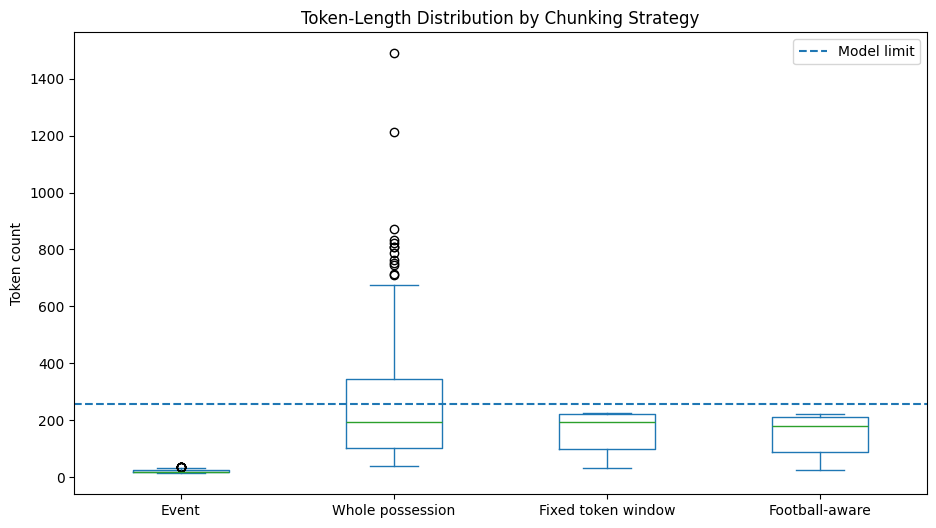

In [29]:
comparison_df = pd.DataFrame({
    "Event": pd.Series(
        [
            chunk["token_count"]
            for chunk in event_chunks
        ]
    ),
    "Whole possession": pd.Series(
        [
            chunk["token_count"]
            for chunk in possession_chunks
        ]
    ),
    "Fixed token window": pd.Series(
        [
            chunk["token_count"]
            for chunk in fixed_token_chunks
        ]
    ),
    "Football-aware": pd.Series(
        [
            chunk["token_count"]
            for chunk in football_aware_chunks
        ]
    ),
})

comparison_df.plot(
    kind="box",
    figsize=(11, 6),
)

plt.axhline(
    MAX_SEQUENCE_LENGTH,
    linestyle="--",
    label="Model limit",
)

plt.ylabel("Token count")
plt.title("Token-Length Distribution by Chunking Strategy")
plt.legend()
plt.show()

# Part VII - Retrieval Comparison

## 17. Why compare retrieval after chunking?

A chunking strategy should not be selected only because its chunks fit under the model limit.

The real objective is retrieval quality.

We therefore perform a small qualitative semantic-search comparison while keeping:

- the same embedding model;
- the same query;
- the same cosine-similarity logic.

This isolates chunking as the main experimental variable.

## 18. Generic chunk encoder

In [30]:
def encode_chunks(
    chunks: list[dict],
) -> np.ndarray:
    """Encode chunk text using normalized sentence embeddings."""

    texts = [
        chunk["text"]
        for chunk in chunks
    ]

    return embedding_model.encode(
        texts,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
        batch_size=64,
    )

For retrieval comparison, we focus on three strategies:

```text
whole possession
fixed token window
football-aware
```

Event-level chunks are intentionally left out of this first embedding comparison because their main limitation is already conceptually clear: they often contain too little sequence context.

They can be included later in the formal evaluation benchmark.

In [31]:
possession_embeddings = encode_chunks(
    possession_chunks
)

fixed_window_embeddings = encode_chunks(
    fixed_token_chunks
)

football_aware_embeddings = encode_chunks(
    football_aware_chunks
)

print(
    "Whole possession:",
    possession_embeddings.shape,
)

print(
    "Fixed token window:",
    fixed_window_embeddings.shape,
)

print(
    "Football-aware:",
    football_aware_embeddings.shape,
)

Batches: 100%|██████████| 7/7 [00:24<00:00,  3.50s/it]

Whole possession: (246, 384)
Fixed token window: (433, 384)
Football-aware: (428, 384)


## 19. Generic semantic search over chunks

In [32]:
def search_chunks(
    query: str,
    chunks: list[dict],
    embeddings: np.ndarray,
    top_k: int = 5,
) -> pd.DataFrame:
    """Retrieve Top-K semantically similar chunks."""

    if not query.strip():
        raise ValueError(
            "The query cannot be empty."
        )

    query_embedding = (
        embedding_model.encode(
            query,
            convert_to_numpy=True,
            normalize_embeddings=True,
        )
    )

    scores = (
        embeddings
        @ query_embedding
    )

    top_k = min(
        top_k,
        len(chunks),
    )

    indices = np.argsort(
        scores
    )[::-1][:top_k]

    results = []

    for rank, index in enumerate(
        indices,
        start=1,
    ):
        chunk = chunks[
            int(index)
        ]

        results.append({
            "rank": rank,
            "score": float(
                scores[index]
            ),
            "chunk_id": chunk[
                "chunk_id"
            ],
            "possession_id": chunk.get(
                "possession_id"
            ),
            "team": chunk.get(
                "possession_team"
            ),
            "start_minute": chunk.get(
                "start_minute"
            ),
            "end_minute": chunk.get(
                "end_minute"
            ),
            "token_count": chunk[
                "token_count"
            ],
            "text": chunk["text"],
        })

    return pd.DataFrame(results)

## 20. Compare one query across strategies

We use the same football question for all three chunk representations:

```text
A dangerous France attack ending with a shot
```

The purpose is not yet to calculate a formal accuracy score.

We inspect whether the retrieved contexts are:

- relevant;
- focused;
- complete enough to understand the football sequence;
- unnecessarily long or truncated.

In [33]:
QUERY = (
    "A dangerous France attack "
    "ending with a shot"
)

retrieval_sets = {
    "Whole possession": (
        possession_chunks,
        possession_embeddings,
    ),
    "Fixed token window": (
        fixed_token_chunks,
        fixed_window_embeddings,
    ),
    "Football-aware": (
        football_aware_chunks,
        football_aware_embeddings,
    ),
}

retrieval_results = {}

for strategy, (
    chunks,
    embeddings,
) in retrieval_sets.items():

    retrieval_results[strategy] = (
        search_chunks(
            query=QUERY,
            chunks=chunks,
            embeddings=embeddings,
            top_k=5,
        )
    )

In [34]:
for strategy, results in retrieval_results.items():
    print("=" * 100)
    print(strategy.upper())
    print("=" * 100)

    display(
        results[
            [
                "rank",
                "score",
                "chunk_id",
                "possession_id",
                "team",
                "start_minute",
                "token_count",
            ]
        ]
    )

WHOLE POSSESSION


,rank,score,chunk_id,possession_id,team,start_minute,token_count
0,1,0.535931,possession_131,131,France,67,110
1,2,0.530106,possession_217,217,France,104,67
2,3,0.524454,possession_213,213,France,99,196
3,4,0.523580,possession_183,183,France,92,148
4,5,0.517279,possession_214,214,France,100,103


FIXED TOKEN WINDOW


,rank,score,chunk_id,possession_id,team,start_minute,token_count
0,1,0.535931,possession_131_window_0,131,France,67,110
1,2,0.530106,possession_217_window_0,217,France,104,67
2,3,0.524454,possession_213_window_0,213,France,99,196
3,4,0.523580,possession_183_window_0,183,France,92,148
4,5,0.519682,possession_18_window_3,18,Argentina,7,48


FOOTBALL-AWARE


,rank,score,chunk_id,possession_id,team,start_minute,token_count
0,1,0.526838,possession_108_football_0,108,France,58,24
1,2,0.524826,possession_183_football_0,183,France,92,133
2,3,0.520673,possession_213_football_0,213,France,99,180
3,4,0.520448,possession_214_football_0,214,France,100,88
4,5,0.518699,possession_140_football_0,140,France,71,24


## 21. Inspect the actual Top-3 contexts

Retrieval should always be evaluated by inspecting the text, not only the similarity score.

The following cell prints the three highest-ranked chunks for each strategy.

In [35]:
for strategy, results in retrieval_results.items():
    print("\n" + "#" * 100)
    print(strategy.upper())
    print("#" * 100)

    for _, result in results.head(3).iterrows():
        print(
            f"\nRank {int(result['rank'])} | "
            f"score={result['score']:.4f} | "
            f"tokens={int(result['token_count'])}"
        )
        print("-" * 100)
        print(result["text"])


####################################################################################################
WHOLE POSSESSION
####################################################################################################

Rank 1 | score=0.5359 | tokens=110
----------------------------------------------------------------------------------------------------
Possession 131. France. Play pattern: From Corner. From 67:13 to 67:15.
67:13 - France: Antoine Griezmann completes a pass to Randal Kolo Muani. 67:15 - Argentina: Alexis Mac Allister is involved in a duel. 67:15 - France: Randal Kolo Muani takes a shot with an xG of 0.096. The shot outcome is Off T. 67:15 - Argentina: Damián Emiliano Martínez performs a goalkeeper action: Shot Faced.

Rank 2 | score=0.5301 | tokens=67
----------------------------------------------------------------------------------------------------
Possession 217. France. Play pattern: From Goal Kick. From 104:02 to 104:05.
104:02 - France: Hugo Lloris attempts a pa

## 22. What should we look for?

When comparing the outputs, ask:

### Relevance

Does the chunk actually describe a France attack?

### Action coverage

Does it include a shot, or only vaguely related attacking actions?

### Context

Can the sequence leading to the shot be understood?

### Noise

Does the chunk contain many unrelated actions?

### Boundary quality

Does the text begin or end in an unnatural place?

### Truncation

Could relevant information have disappeared because the original possession exceeded the model limit?

These questions will later become part of a formal retrieval-evaluation methodology.

# Final Conclusion

This notebook evaluated several chunking strategies for semantic retrieval in MatchMind while keeping the same embedding model, `sentence-transformers/all-MiniLM-L6-v2`.

The experiments confirmed that chunking is not only a preprocessing detail. It directly determines how much football context is preserved in each embedding and whether the embedding model can represent the complete input without truncation.

## Main findings

The whole-possession baseline produced 246 retrieval documents, but 91 of them exceeded the model's 256-token input limit. This represents 36.99% of the corpus and confirms that complete possessions cannot be used safely as the final retrieval representation.

The longest possession contained 1,490 tokens, meaning that only a small fraction of the original text could influence its embedding when encoded without additional chunking.

The event-level strategy completely avoided the model-length problem and produced very small retrieval units. However, individual events often lacked enough context to represent multi-action football sequences.

The fixed token-window strategy also eliminated truncation and created chunks below the model limit. However, inspection showed that token-based splitting can create unnatural boundaries and even begin chunks inside tokenized words or football actions.

The football-aware strategy produced 428 chunks, preserved complete event descriptions, retained possession identity, and kept every chunk within the selected 220-token budget.

The maximum football-aware chunk length was 220 tokens, and no football-aware chunk exceeded the embedding model limit.

## Retrieval observations

The qualitative semantic-search experiment also showed that high cosine similarity does not guarantee football relevance.

Some highly ranked results matched keywords such as `shot` without representing the complete attacking situation described by the query.

Other football-aware chunks provided more focused sequences containing ball recoveries, carries, passes, and shots.

This demonstrates that chunk quality and embedding similarity alone are not sufficient to determine retrieval quality.

A formal retrieval benchmark is required before selecting the final chunking strategy.

## Current MatchMind decision

At this stage, football-aware chunking is the strongest candidate for MatchMind because it combines:

- domain-aware event boundaries;
- possession-level context;
- safe token lengths;
- limited overlap between neighboring chunks;
- compatibility with the current embedding model.

However, the current configuration:

```text
220-token maximum chunk size
1-event overlap